In [1]:
# Install required packages using magic commands
import sys
!{sys.executable} -m pip install pandas>=1.5.0 numpy>=1.21.0 matplotlib>=3.5.0 seaborn>=0.11.0 scikit-learn>=1.1.0 --quiet

# Alternative magic command method
# %pip install pandas numpy matplotlib seaborn scikit-learn --quiet

#Install additional packages for enhanced EDA
!{sys.executable} -m pip install wordcloud plotly textstat --quiet

print("✅ Packages installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.1/239.1 kB 5.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 21.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.6 MB/s eta 0:00:00:00:01
✅ Packages installed successfully!


# Exploratory Data Analysis (EDA) for Symbolic Math Reasoning Assistant (SMRA)

This notebook performs exploratory data analysis on the math datasets to inform model development.

## Steps
- Load datasets
- Overview and summary statistics
- Visualize key features
- Insights for modeling


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import MathDatasetLoader
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print('Libraries imported successfully!')


Libraries imported successfully!


## 1. Load Datasets


In [3]:
loader = MathDatasetLoader(data_dir="Dataset")
datasets = loader.get_all_datasets()
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


Loaded GSM8K train dataset from local file
Loaded GSM8K test dataset from local file
Loaded MathQA train dataset from local file
Loaded MathQA test dataset from local file
Loaded MathQA validation dataset from local file
Loaded SVAMP train dataset from local file
Loaded SVAMP test dataset from local file
gsm8k_train: (7473, 2)
gsm8k_test: (1319, 2)
mathqa_train: (29837, 7)
mathqa_test: (2985, 7)
mathqa_validation: (4475, 7)
svamp_train: (700, 7)
svamp_test: (300, 7)


## 2. Overview and Summary Statistics

In [4]:
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.head())
    print(df.describe(include='all'))



gsm8k_train


,question,answer
0,Natalia sold clips to 48 of her friends in Apr...,Natalia sold 48/2 = <<48/2=24>>24 clips in May...
1,Weng earns $12 an hour for babysitting. Yester...,Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...
2,Betty is saving money for a new wallet which c...,"In the beginning, Betty has only 100 / 2 = $<<..."
3,"Julie is reading a 120-page book. Yesterday, s...",Maila read 12 x 2 = <<12*2=24>>24 pages today....
4,James writes a 3-page letter to 2 different fr...,He writes each friend 3*2=<<3*2=6>>6 pages a w...


                                                 question  \
count                                                7473   
unique                                               7473   
top     Natalia sold clips to 48 of her friends in Apr...   
freq                                                    1   

                                                   answer  
count                                                7473  
unique                                               7473  
top     Natalia sold 48/2 = <<48/2=24>>24 clips in May...  
freq                                                    1  

gsm8k_test


,question,answer
0,Janet’s ducks lay 16 eggs per day. She eats th...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...
1,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...
2,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...
3,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...
4,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t..."


                                                 question  \
count                                                1319   
unique                                               1319   
top     Janet’s ducks lay 16 eggs per day. She eats th...   
freq                                                    1   

                                                   answer  
count                                                1319  
unique                                               1319  
top     Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...  
freq                                                    1  

mathqa_train


...

                                                  Problem  \
count                                                4475   
unique                                               4475   
top     a multiple choice test consists of 4 questions...   
freq                                                    1   

                                                Rationale  \
count                                                4475   
unique                                               4462   
top     "before you tackle this question you must firs...   
freq                                                    3   

                                      options correct  \
count                                    4475    4475   
unique                                   4158       5   
top     a ) 1 , b ) 2 , c ) 3 , d ) 4 , e ) 5       b   
freq                                       26     984   

                          annotated_formula  \
count                                  4475   
unique  

,ID,Body,Question,Equation,Answer,Type,question_concat
0,chal-777,There are 87 oranges and 290 bananas in Philip...,How big is each group of bananas?,( 290.0 / 2.0 ),145,Common-Division,There are 87 oranges and 290 bananas in Philip...
1,chal-508,Marco and his dad went strawberry picking. Mar...,How much did Marco's strawberries weigh?,( 30.0 - 11.0 ),19,Subtraction,Marco and his dad went strawberry picking. Mar...
2,chal-896,Edward spent $ 6 to buy 2 books each book cost...,How much did each book cost?,( 6.0 / 2.0 ),3,Common-Division,Edward spent $ 6 to buy 2 books each book cost...
3,chal-923,Frank was reading through his favorite book. T...,How many pages are in each chapter?,( 594.0 / 3.0 ),198,Common-Division,Frank was reading through his favorite book. T...
4,chal-34,There were 78 dollars in Olivia's wallet. She ...,How much money does she have left?,( 78.0 - 15.0 ),63,Subtraction,There were 78 dollars in Olivia's wallet. She ...


              ID                                               Body  \
count        700                                                700   
unique       700                                                700   
top     chal-777  There are 87 oranges and 290 bananas in Philip...   
freq           1                                                  1   
mean         NaN                                                NaN   
std          NaN                                                NaN   
min          NaN                                                NaN   
25%          NaN                                                NaN   
50%          NaN                                                NaN   
75%          NaN                                                NaN   
max          NaN                                                NaN   

                           Question       Equation        Answer         Type  \
count                           700            700  7.000000e+02  

,ID,Body,Question,Equation,Answer,Type,question_concat
0,chal-736,Winter is almost here and most animals are mig...,How many more bird families flew away to afric...,( 62.0 - 35.0 ),27,Subtraction,Winter is almost here and most animals are mig...
1,chal-162,Paige raised 7 goldfish and 12 catfish in the ...,How many fishes disappeared?,( ( 7.0 + 12.0 ) - 15.0 ),4,Subtraction,Paige raised 7 goldfish and 12 catfish in the ...
2,chal-349,Marco and his dad went strawberry picking. Tog...,How much did his dad's strawberries weigh now?,( ( 22.0 - 36.0 ) + 30.0 ),16,Addition,Marco and his dad went strawberry picking. Tog...
3,chal-390,Debby bought 200 water bottles and 256 soda bo...,How many days would the soda bottles last?,( 256.0 / 4.0 ),64,Common-Division,Debby bought 200 water bottles and 256 soda bo...
4,chal-781,There were 106 dollars in Olivia's wallet. Aft...,How much did she spend at the supermarket?,( ( 106.0 - 26.0 ) - 49.0 ),31,Subtraction,There were 106 dollars in Olivia's wallet. Aft...


              ID                                               Body  \
count        300                                                300   
unique       300                                                300   
top     chal-736  Winter is almost here and most animals are mig...   
freq           1                                                  1   
mean         NaN                                                NaN   
std          NaN                                                NaN   
min          NaN                                                NaN   
25%          NaN                                                NaN   
50%          NaN                                                NaN   
75%          NaN                                                NaN   
max          NaN                                                NaN   

                                                 Question       Equation  \
count                                                 300            30

## 3. Difficulty and Subject Analysis


In [5]:
# Enhanced EDA: Comprehensive Analysis of Math Datasets
print("🔍 Starting comprehensive EDA analysis...")

# First, let's update our dataset loading to use the preprocessed data
import re
from collections import Counter
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


🔍 Starting comprehensive EDA analysis...


In [6]:
## 5. Complete Preprocessing Pipeline

def preprocess_datasets(datasets):
    """
    Complete preprocessing pipeline for all math datasets
    """
    preprocessed = {}
    
    for name, df in datasets.items():
        print(f"🔄 Preprocessing {name}...")
        df_processed = df.copy()
        
        # Standardize problem text column
        if 'question' in df.columns:
            df_processed['problem_text'] = df_processed['question']
        elif 'Problem' in df.columns:
            df_processed['problem_text'] = df_processed['Problem']
        elif 'sQuestion' in df.columns:
            df_processed['problem_text'] = df_processed['sQuestion']
        elif 'question_concat' in df.columns:
            df_processed['problem_text'] = df_processed['question_concat']
        
        # Standardize answer column
        if 'answer' in df.columns:
            df_processed['solution_text'] = df_processed['answer']
        elif 'Rationale' in df.columns:
            df_processed['solution_text'] = df_processed['Rationale']
        elif 'final_answer' in df.columns:
            df_processed['solution_text'] = df_processed['final_answer']
        
        # Extract text features
        if 'problem_text' in df_processed.columns:
            df_processed['text_length'] = df_processed['problem_text'].str.len()
            df_processed['word_count'] = df_processed['problem_text'].str.split().str.len()
            df_processed['sentence_count'] = df_processed['problem_text'].str.count(r'[.!?]') + 1
            
            # Mathematical operators count
            math_ops = ['+', '-', '*', '/', '=', '>', '<', '≥', '≤', '∫', '∑', '√']
            df_processed['math_ops_count'] = df_processed['problem_text'].apply(
                lambda x: sum(str(x).count(op) for op in math_ops) if pd.notna(x) else 0
            )
            
            # Number count in problem
            df_processed['number_count'] = df_processed['problem_text'].apply(
                lambda x: len(re.findall(r'\b\d+\.?\d*\b', str(x))) if pd.notna(x) else 0
            )
        
        # Standardize difficulty if available
        if 'difficulty' in df_processed.columns:
            df_processed['difficulty_level'] = df_processed['difficulty']
        elif 'difficulty_level' not in df_processed.columns:
            # Infer difficulty based on text complexity
            if 'text_length' in df_processed.columns:
                df_processed['difficulty_level'] = pd.cut(
                    df_processed['text_length'], 
                    bins=[0, 50, 150, 500, float('inf')],
                    labels=['basic', 'intermediate', 'advanced', 'expert']
                )
        
        # Add dataset identifier
        df_processed['dataset_name'] = name
        
        preprocessed[name] = df_processed
        
    print("✅ Preprocessing completed!")
    return preprocessed

# Apply preprocessing
preprocessed_datasets = preprocess_datasets(datasets)


🔄 Preprocessing gsm8k_train...
🔄 Preprocessing gsm8k_test...
🔄 Preprocessing mathqa_train...
🔄 Preprocessing mathqa_test...
🔄 Preprocessing mathqa_validation...
🔄 Preprocessing svamp_train...
🔄 Preprocessing svamp_test...
✅ Preprocessing completed!


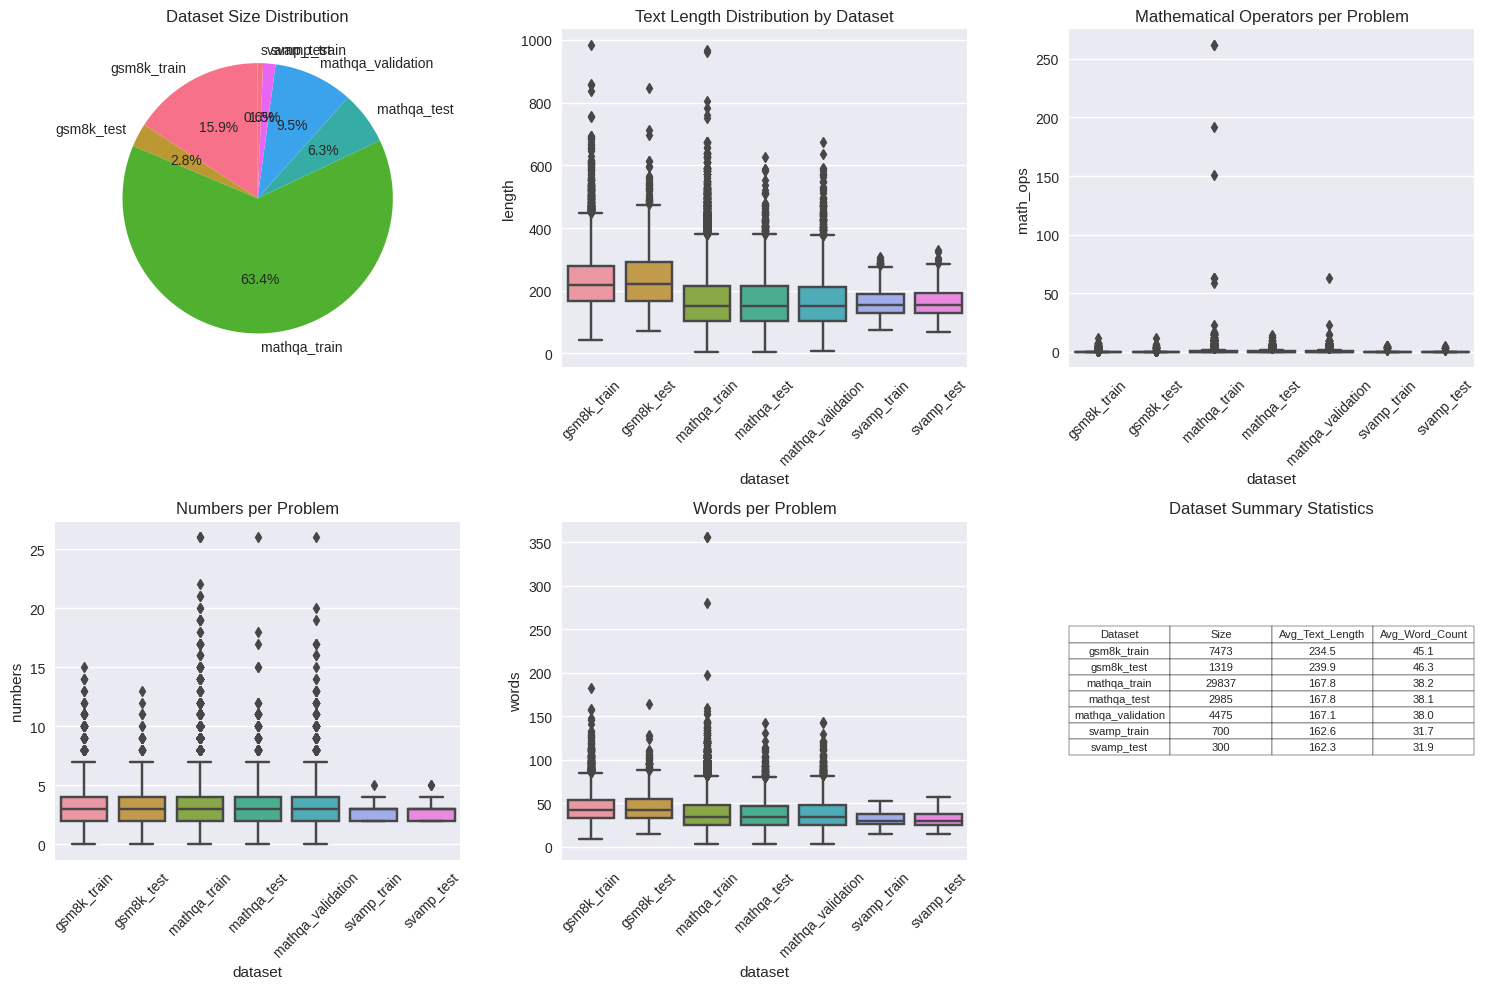

In [7]:
## 6. Dataset Overview and Statistics

def analyze_dataset_overview(preprocessed_datasets):
    """Comprehensive overview of all datasets"""
    
    # Combine all datasets for overall statistics
    combined_data = []
    for name, df in preprocessed_datasets.items():
        temp_df = df.copy()
        temp_df['dataset'] = name
        combined_data.append(temp_df)
    
    # Dataset size comparison
    plt.figure(figsize=(15, 10))
    
    # Dataset sizes
    plt.subplot(2, 3, 1)
    sizes = [len(df) for df in preprocessed_datasets.values()]
    names = list(preprocessed_datasets.keys())
    plt.pie(sizes, labels=names, autopct='%1.1f%%', startangle=90)
    plt.title('Dataset Size Distribution')
    
    # Text length comparison across datasets
    plt.subplot(2, 3, 2)
    text_lengths = []
    dataset_labels = []
    for name, df in preprocessed_datasets.items():
        if 'text_length' in df.columns:
            text_lengths.extend(df['text_length'].dropna().tolist())
            dataset_labels.extend([name] * len(df['text_length'].dropna()))
    
    df_text = pd.DataFrame({'length': text_lengths, 'dataset': dataset_labels})
    sns.boxplot(data=df_text, x='dataset', y='length')
    plt.xticks(rotation=45)
    plt.title('Text Length Distribution by Dataset')
    
    # Mathematical complexity
    plt.subplot(2, 3, 3)
    math_complexity = []
    dataset_labels_math = []
    for name, df in preprocessed_datasets.items():
        if 'math_ops_count' in df.columns:
            math_complexity.extend(df['math_ops_count'].dropna().tolist())
            dataset_labels_math.extend([name] * len(df['math_ops_count'].dropna()))
    
    if math_complexity:
        df_math = pd.DataFrame({'math_ops': math_complexity, 'dataset': dataset_labels_math})
        sns.boxplot(data=df_math, x='dataset', y='math_ops')
        plt.xticks(rotation=45)
        plt.title('Mathematical Operators per Problem')
    
    # Number count distribution
    plt.subplot(2, 3, 4)
    number_counts = []
    dataset_labels_num = []
    for name, df in preprocessed_datasets.items():
        if 'number_count' in df.columns:
            number_counts.extend(df['number_count'].dropna().tolist())
            dataset_labels_num.extend([name] * len(df['number_count'].dropna()))
    
    if number_counts:
        df_num = pd.DataFrame({'numbers': number_counts, 'dataset': dataset_labels_num})
        sns.boxplot(data=df_num, x='dataset', y='numbers')
        plt.xticks(rotation=45)
        plt.title('Numbers per Problem')
    
    # Word count distribution
    plt.subplot(2, 3, 5)
    word_counts = []
    dataset_labels_words = []
    for name, df in preprocessed_datasets.items():
        if 'word_count' in df.columns:
            word_counts.extend(df['word_count'].dropna().tolist())
            dataset_labels_words.extend([name] * len(df['word_count'].dropna()))
    
    if word_counts:
        df_words = pd.DataFrame({'words': word_counts, 'dataset': dataset_labels_words})
        sns.boxplot(data=df_words, x='dataset', y='words')
        plt.xticks(rotation=45)
        plt.title('Words per Problem')
    
    # Dataset summary table
    plt.subplot(2, 3, 6)
    summary_data = []
    for name, df in preprocessed_datasets.items():
        summary_data.append({
            'Dataset': name,
            'Size': len(df),
            'Avg_Text_Length': df['text_length'].mean() if 'text_length' in df.columns else 'N/A',
            'Avg_Word_Count': df['word_count'].mean() if 'word_count' in df.columns else 'N/A'
        })
    
    summary_df = pd.DataFrame(summary_data)
    plt.axis('tight')
    plt.axis('off')
    table = plt.table(cellText=summary_df.round(1).values, 
                     colLabels=summary_df.columns,
                     cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    plt.title('Dataset Summary Statistics')
    
    plt.tight_layout()
    plt.show()
    
    return summary_df

summary_stats = analyze_dataset_overview(preprocessed_datasets)


📊 Analyzing difficulty patterns...


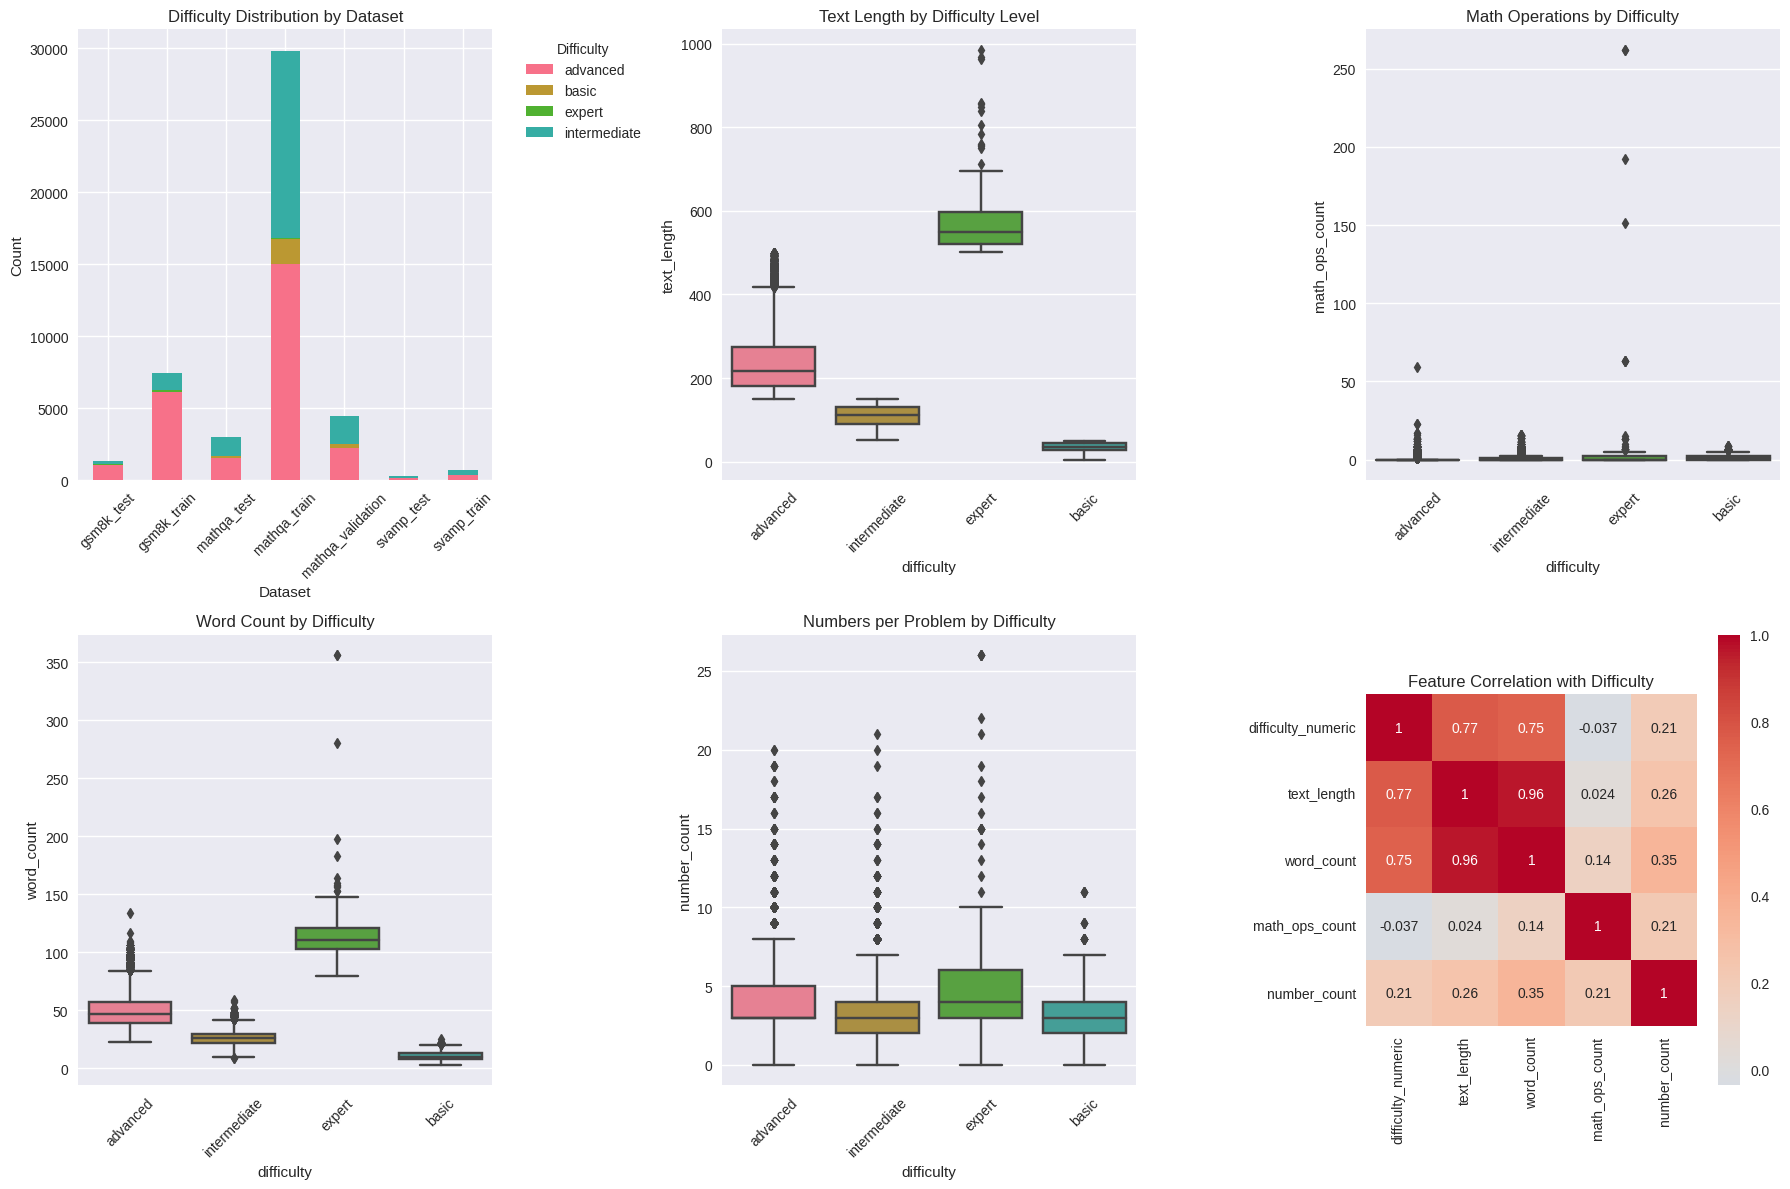


📈 Difficulty Level Statistics:
             text_length        word_count        math_ops_count         \
                    mean    std       mean    std           mean    std   
difficulty                                                                
advanced          236.82  71.88      49.89  14.27           0.45   1.13   
basic              34.33  10.87      10.79   4.01           1.31   1.62   
expert            573.29  77.30     115.18  27.31           4.87  26.23   
intermediate      108.18  26.68      26.06   6.45           0.64   1.53   

             number_count        
                     mean   std  
difficulty                       
advanced             3.75  1.90  
basic                2.91  1.56  
expert               5.38  4.32  
intermediate         3.00  1.59  


In [8]:
## 7. Deep Analysis: Problem Difficulty Patterns

def analyze_difficulty_patterns(preprocessed_datasets):
    """Deep analysis of problem difficulty across datasets"""
    
    print("📊 Analyzing difficulty patterns...")
    
    # Collect difficulty data from all datasets
    difficulty_data = []
    for name, df in preprocessed_datasets.items():
        if 'difficulty_level' in df.columns:
            for _, row in df.iterrows():
                difficulty_data.append({
                    'dataset': name,
                    'difficulty': str(row['difficulty_level']),
                    'text_length': row.get('text_length', 0),
                    'word_count': row.get('word_count', 0),
                    'math_ops_count': row.get('math_ops_count', 0),
                    'number_count': row.get('number_count', 0)
                })
    
    if not difficulty_data:
        print("⚠️ No difficulty data found in datasets")
        return
    
    difficulty_df = pd.DataFrame(difficulty_data)
    
    # Create comprehensive difficulty analysis
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Difficulty distribution across datasets
    axes[0, 0].set_title('Difficulty Distribution by Dataset')
    difficulty_counts = difficulty_df.groupby(['dataset', 'difficulty']).size().unstack(fill_value=0)
    difficulty_counts.plot(kind='bar', stacked=True, ax=axes[0, 0])
    axes[0, 0].set_xlabel('Dataset')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend(title='Difficulty', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Text length vs difficulty
    axes[0, 1].set_title('Text Length by Difficulty Level')
    sns.boxplot(data=difficulty_df, x='difficulty', y='text_length', ax=axes[0, 1])
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Mathematical complexity vs difficulty
    axes[0, 2].set_title('Math Operations by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='math_ops_count', ax=axes[0, 2])
    axes[0, 2].tick_params(axis='x', rotation=45)
    
    # 4. Word count vs difficulty
    axes[1, 0].set_title('Word Count by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='word_count', ax=axes[1, 0])
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # 5. Numbers per problem vs difficulty
    axes[1, 1].set_title('Numbers per Problem by Difficulty')
    sns.boxplot(data=difficulty_df, x='difficulty', y='number_count', ax=axes[1, 1])
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    # 6. Correlation heatmap
    axes[1, 2].set_title('Feature Correlation with Difficulty')
    # Create difficulty encoding for correlation
    difficulty_mapping = {'basic': 1, 'intermediate': 2, 'advanced': 3, 'expert': 4}
    difficulty_df['difficulty_numeric'] = difficulty_df['difficulty'].apply(lambda x: difficulty_mapping.get(x, 0))
    
    correlation_features = ['difficulty_numeric', 'text_length', 'word_count', 'math_ops_count', 'number_count']
    correlation_matrix = difficulty_df[correlation_features].corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, ax=axes[1, 2])
    
    plt.tight_layout()
    plt.show()
    
    # Print difficulty statistics
    print("\n📈 Difficulty Level Statistics:")
    difficulty_stats = difficulty_df.groupby('difficulty').agg({
        'text_length': ['mean', 'std'],
        'word_count': ['mean', 'std'],
        'math_ops_count': ['mean', 'std'],
        'number_count': ['mean', 'std']
    }).round(2)
    
    print(difficulty_stats)
    
    return difficulty_df

difficulty_analysis = analyze_difficulty_patterns(preprocessed_datasets)


🏷️ Analyzing label types and categories...

📋 Analyzing gsm8k_train:
  Solution Analysis:
    - Problems with calculations: 7472
    - Problems with step-by-step solutions: 1811
    - Problems with numerical answers: 7473

📋 Analyzing gsm8k_test:
  Solution Analysis:
    - Problems with calculations: 1319
    - Problems with step-by-step solutions: 304
    - Problems with numerical answers: 1319

📋 Analyzing mathqa_train:
  category: {'general': 13273, 'physics': 7063, 'gain': 5120, 'geometry': 2117, 'other': 1814, 'probability': 450}
  Solution Analysis:
    - Problems with calculations: 29117
    - Problems with step-by-step solutions: 5752
    - Problems with numerical answers: 29754

📋 Analyzing mathqa_test:
  category: {'general': 1301, 'physics': 702, 'gain': 558, 'geometry': 200, 'other': 172, 'probability': 52}
  Solution Analysis:
    - Problems with calculations: 2904
    - Problems with step-by-step solutions: 614
    - Problems with numerical answers: 2978

📋 Analyzing math

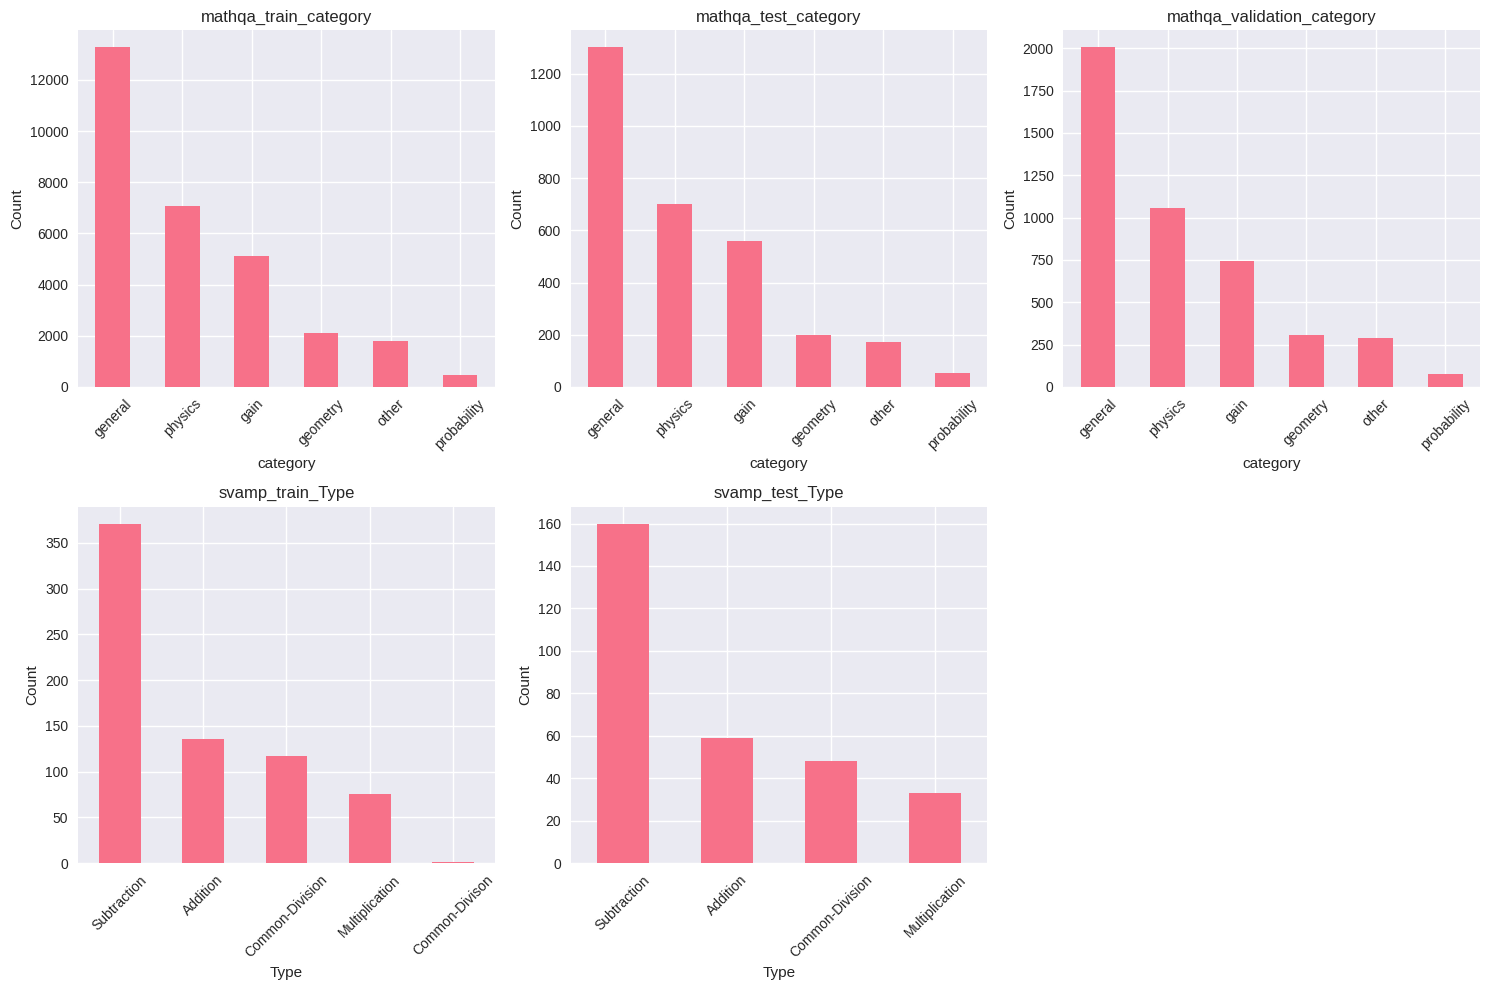

In [9]:
## 8. Label Types and Category Analysis

def analyze_label_categories(preprocessed_datasets):
    """Analyze different types of labels and categories across datasets"""
    
    print("🏷️ Analyzing label types and categories...")
    
    # Collect category information from all datasets
    category_analysis = {}
    
    for name, df in preprocessed_datasets.items():
        print(f"\n📋 Analyzing {name}:")
        
        # Look for category columns
        category_columns = [col for col in df.columns if 'category' in col.lower() or 'type' in col.lower()]
        
        for col in category_columns:
            if col in df.columns:
                print(f"  {col}: {df[col].value_counts().to_dict()}")
                category_analysis[f"{name}_{col}"] = df[col].value_counts()
        
        # Analyze answer types for mathematical problems
        if 'solution_text' in df.columns:
            # Analyze solution characteristics
            solutions = df['solution_text'].dropna().astype(str)
            
            # Check for different solution patterns
            has_calculation = solutions.str.contains(r'[+\-*/=]', regex=True).sum()
            has_steps = solutions.str.contains(r'step|then|next|first', case=False, regex=True).sum()
            has_numbers = solutions.str.contains(r'\d+', regex=True).sum()
            
            print(f"  Solution Analysis:")
            print(f"    - Problems with calculations: {has_calculation}")
            print(f"    - Problems with step-by-step solutions: {has_steps}")
            print(f"    - Problems with numerical answers: {has_numbers}")
    
    # Visualize category distributions
    if category_analysis:
        n_categories = len(category_analysis)
        n_cols = min(3, n_categories)
        n_rows = (n_categories + n_cols - 1) // n_cols
        
        plt.figure(figsize=(15, 5 * n_rows))
        
        for i, (category_name, counts) in enumerate(category_analysis.items(), 1):
            plt.subplot(n_rows, n_cols, i)
            counts.plot(kind='bar')
            plt.title(f'{category_name}')
            plt.xticks(rotation=45)
            plt.ylabel('Count')
        
        plt.tight_layout()
        plt.show()
    
    return category_analysis

category_analysis = analyze_label_categories(preprocessed_datasets)


🔢 Analyzing mathematical operation patterns...

📊 gsm8k_train - Mathematical Operations:
  Addition: 1842 problems
  Subtraction: 680 problems
  Multiplication: 5947 problems
  Division: 1170 problems
  Percentage: 937 problems
  Fractions: 1686 problems
  Geometry: 62 problems
  Algebra: 6585 problems
  Statistics: 235 problems

📊 gsm8k_test - Mathematical Operations:
  Addition: 324 problems
  Subtraction: 129 problems
  Multiplication: 1069 problems
  Division: 211 problems
  Percentage: 172 problems
  Fractions: 300 problems
  Geometry: 5 problems
  Algebra: 1140 problems
  Statistics: 48 problems

📊 mathqa_train - Mathematical Operations:
  Addition: 5532 problems
  Subtraction: 2312 problems
  Multiplication: 23893 problems
  Division: 7192 problems
  Percentage: 6835 problems
  Fractions: 1594 problems
  Geometry: 2149 problems
  Algebra: 18927 problems
  Statistics: 3484 problems

📊 mathqa_test - Mathematical Operations:
  Addition: 543 problems
  Subtraction: 222 problems
  Mu

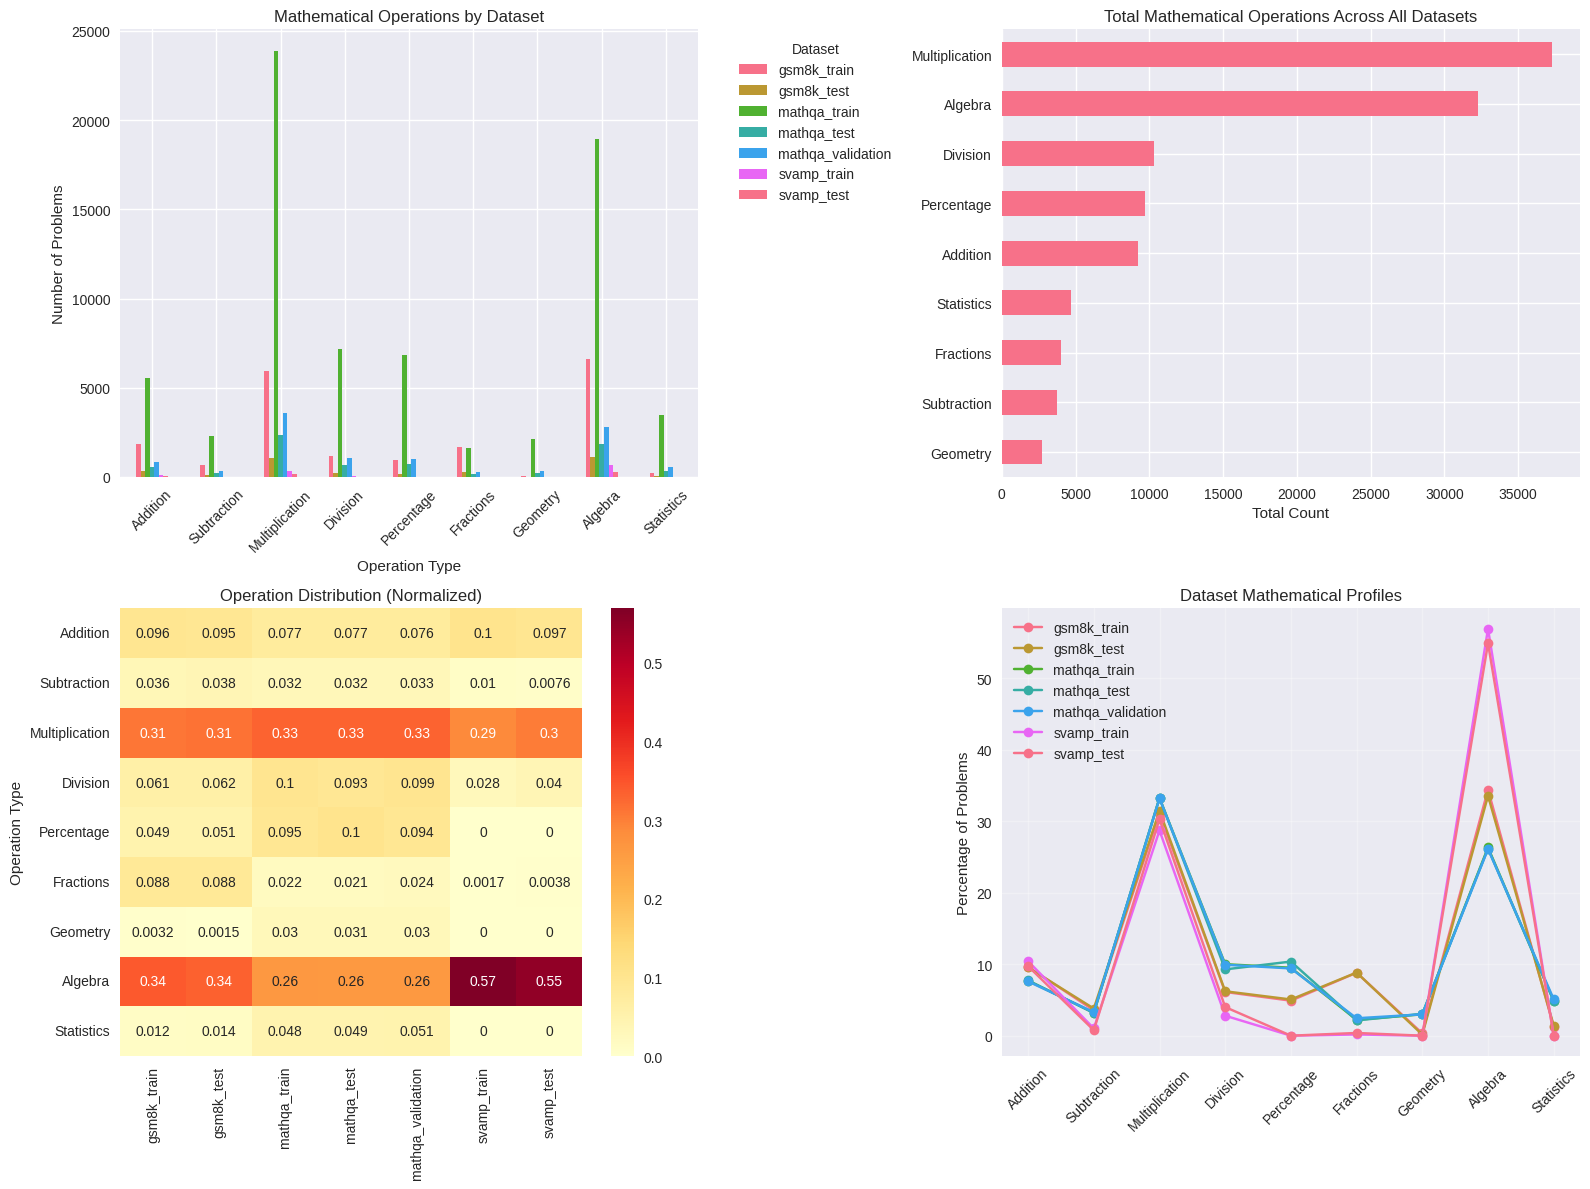

In [10]:
## 9. Mathematical Operation Patterns

def analyze_math_operations(preprocessed_datasets):
    """Deep analysis of mathematical operations and patterns in problems"""
    
    print("🔢 Analyzing mathematical operation patterns...")
    
    # Define mathematical operation patterns
    operation_patterns = {
        'Addition': r'[+\s]plus\s|\sadd\s|\ssum\s|together|\stotal',
        'Subtraction': r'[-\s]minus\s|\ssubtract\s|\sdifference\s|\sless\s|\sremaining',
        'Multiplication': r'[*×]\s|\smultiply\s|\stimes\s|\sof\s|\seach',
        'Division': r'[/÷]\s|\sdivide\s|\ssplit\s|\sper\s|\sshare',
        'Percentage': r'%\s|\spercent\s|\spercentage',
        'Fractions': r'\d+/\d+|\sfraction|\shalf|\sthird|\squarter',
        'Geometry': r'area\s|\sperimeter\s|\svolume\s|\sradius\s|\sdiameter',
        'Algebra': r'[xy]\s|\sequation\s|\ssolve\s|\svariable',
        'Statistics': r'average\s|\smean\s|\smedian\s|\smode\s|\sprobability'
    }
    
    # Analyze operation patterns across datasets
    operation_results = {}
    
    for name, df in preprocessed_datasets.items():
        if 'problem_text' in df.columns:
            problems = df['problem_text'].fillna('').astype(str).str.lower()
            
            operation_counts = {}
            for op_name, pattern in operation_patterns.items():
                count = problems.str.contains(pattern, regex=True, case=False).sum()
                operation_counts[op_name] = count
            
            operation_results[name] = operation_counts
            print(f"\n📊 {name} - Mathematical Operations:")
            for op, count in operation_counts.items():
                if count > 0:
                    print(f"  {op}: {count} problems")
    
    # Visualize operation patterns
    if operation_results:
        # Create a comprehensive visualization
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Operation distribution by dataset
        op_df = pd.DataFrame(operation_results).fillna(0)
        op_df.plot(kind='bar', ax=axes[0, 0])
        axes[0, 0].set_title('Mathematical Operations by Dataset')
        axes[0, 0].set_xlabel('Operation Type')
        axes[0, 0].set_ylabel('Number of Problems')
        axes[0, 0].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Total operations across all datasets
        total_ops = op_df.sum(axis=1).sort_values(ascending=True)
        total_ops.plot(kind='barh', ax=axes[0, 1])
        axes[0, 1].set_title('Total Mathematical Operations Across All Datasets')
        axes[0, 1].set_xlabel('Total Count')
        
        # 3. Operation complexity heatmap
        op_df_norm = op_df.div(op_df.sum(axis=0), axis=1).fillna(0)
        sns.heatmap(op_df_norm, annot=True, cmap='YlOrRd', ax=axes[1, 0])
        axes[1, 0].set_title('Operation Distribution (Normalized)')
        axes[1, 0].set_ylabel('Operation Type')
        
        # 4. Dataset operation profiles
        axes[1, 1].set_title('Dataset Mathematical Profiles')
        for dataset in op_df.columns:
            if op_df[dataset].sum() > 0:  # Only plot datasets with operations
                values = op_df[dataset] / op_df[dataset].sum() * 100  # Convert to percentages
                axes[1, 1].plot(values.values, label=dataset, marker='o')
        
        axes[1, 1].set_xticks(range(len(op_df.index)))
        axes[1, 1].set_xticklabels(op_df.index, rotation=45)
        axes[1, 1].set_ylabel('Percentage of Problems')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return operation_results

math_operations = analyze_math_operations(preprocessed_datasets)


📚 Analyzing text complexity and readability...

📊 gsm8k_train - Text Complexity Metrics:
  Average word length: 4.20
  Unique words ratio: 0.77
  Punctuation density: 0.0231

📊 gsm8k_test - Text Complexity Metrics:
  Average word length: 4.18
  Unique words ratio: 0.77
  Punctuation density: 0.0230

📊 mathqa_train - Text Complexity Metrics:
  Average word length: 3.33
  Unique words ratio: 0.73
  Punctuation density: 0.0249

📊 mathqa_test - Text Complexity Metrics:
  Average word length: 3.34
  Unique words ratio: 0.72
  Punctuation density: 0.0247

📊 mathqa_validation - Text Complexity Metrics:
  Average word length: 3.33
  Unique words ratio: 0.73
  Punctuation density: 0.0249

📊 svamp_train - Text Complexity Metrics:
  Average word length: 4.16
  Unique words ratio: 0.78
  Punctuation density: 0.0189

📊 svamp_test - Text Complexity Metrics:
  Average word length: 4.11
  Unique words ratio: 0.79
  Punctuation density: 0.0190


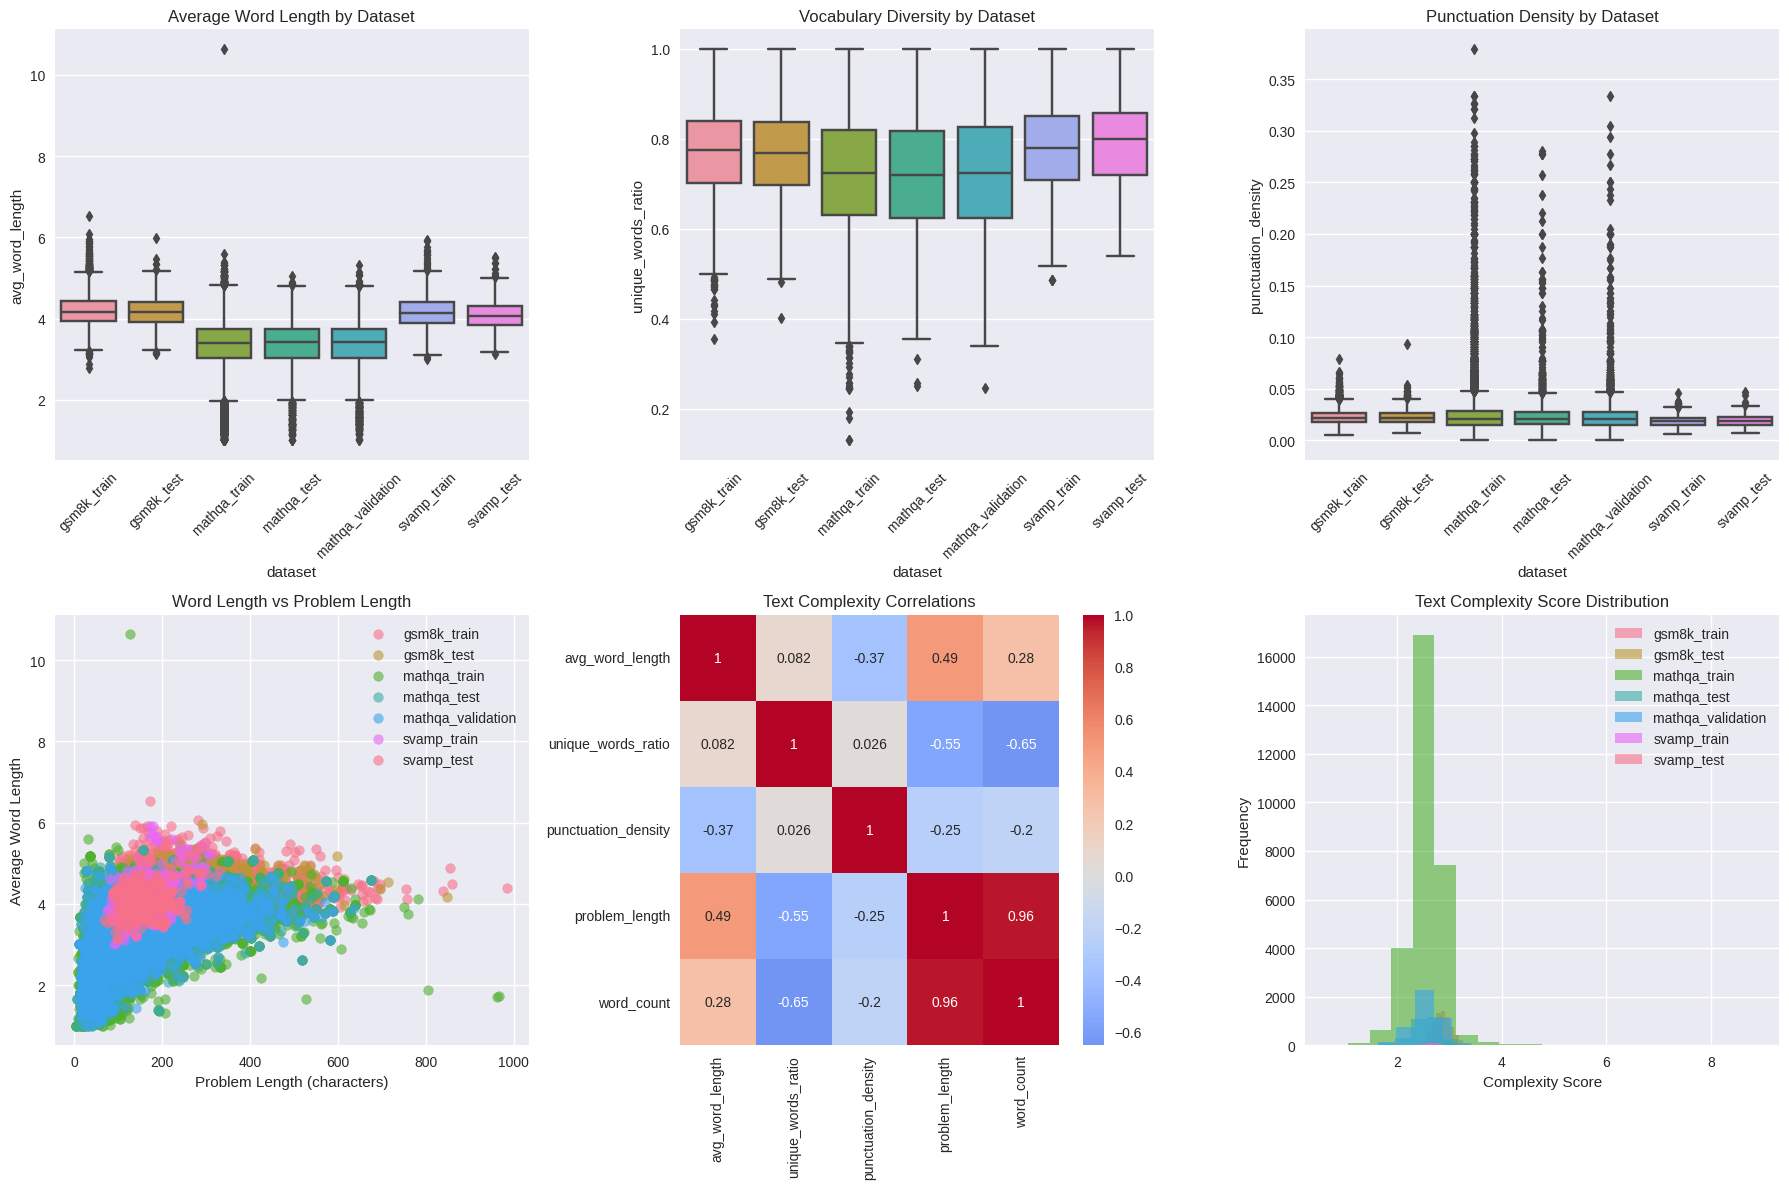

In [ ]:
## 10. Text Complexity and Readability Analysis

def analyze_text_complexity(preprocessed_datasets):
    """Analyze text complexity and readability of math problems"""
    
    print("📚 Analyzing text complexity and readability...")
    
    complexity_results = {}
    
    for name, df in preprocessed_datasets.items():
        if 'problem_text' in df.columns:
            problems = df['problem_text'].fillna('').astype(str)
            
            # Calculate various complexity metrics
            complexity_metrics = {
                'avg_word_length': problems.apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0),
                'unique_words_ratio': problems.apply(lambda x: len(set(x.split())) / len(x.split()) if x.split() else 0),
                'punctuation_density': problems.apply(lambda x: sum(1 for c in x if c in '.,!?;:') / len(x) if x else 0),
                'capital_letter_ratio': problems.apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if x else 0)
            }
            
            complexity_df = pd.DataFrame(complexity_metrics)
            complexity_df['dataset'] = name
            complexity_df['problem_length'] = df.get('text_length', 0)
            complexity_df['word_count'] = df.get('word_count', 0)
            
            
            # Calculate composite complexity score
            complexity_df['complexity_score'] = (
            complexity_df['avg_word_length'] * 0.3 +
            (1 - complexity_df['unique_words_ratio']) * 0.3 +
            complexity_df['punctuation_density'] * 100 * 0.2 +
            np.log1p(complexity_df['problem_length']) * 0.2
            )

            complexity_results[name] = complexity_df
            
            print(f"\n📊 {name} - Text Complexity Metrics:")
            print(f"  Average word length: {complexity_df['avg_word_length'].mean():.2f}")
            print(f"  Unique words ratio: {complexity_df['unique_words_ratio'].mean():.2f}")
            print(f"  Punctuation density: {complexity_df['punctuation_density'].mean():.4f}")
    
    # Combine all complexity data
    if complexity_results:
        all_complexity = pd.concat(complexity_results.values(), ignore_index=True)
        
        # Create complexity analysis visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # 1. Average word length by dataset
        axes[0, 0].set_title('Average Word Length by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='avg_word_length', ax=axes[0, 0])
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Unique words ratio
        axes[0, 1].set_title('Vocabulary Diversity by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='unique_words_ratio', ax=axes[0, 1])
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Punctuation density
        axes[0, 2].set_title('Punctuation Density by Dataset')
        sns.boxplot(data=all_complexity, x='dataset', y='punctuation_density', ax=axes[0, 2])
        axes[0, 2].tick_params(axis='x', rotation=45)
        
        # 4. Word length vs problem length correlation
        axes[1, 0].set_title('Word Length vs Problem Length')
        for dataset in all_complexity['dataset'].unique():
            subset = all_complexity[all_complexity['dataset'] == dataset]
            axes[1, 0].scatter(subset['problem_length'], subset['avg_word_length'], 
                             label=dataset, alpha=0.6)
        axes[1, 0].set_xlabel('Problem Length (characters)')
        axes[1, 0].set_ylabel('Average Word Length')
        axes[1, 0].legend()
        
        # 5. Complexity correlation matrix
        numeric_cols = ['avg_word_length', 'unique_words_ratio', 'punctuation_density', 
                       'problem_length', 'word_count']
        correlation_matrix = all_complexity[numeric_cols].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
        axes[1, 1].set_title('Text Complexity Correlations')
        
        # 6. Complexity distribution
        axes[1, 2].set_title('Text Complexity Score Distribution')
        
        for dataset in all_complexity['dataset'].unique():
            subset = all_complexity[all_complexity['dataset'] == dataset]
            axes[1, 2].hist(subset['complexity_score'], alpha=0.6, label=dataset, bins=20)
        axes[1, 2].set_xlabel('Complexity Score')
        axes[1, 2].set_ylabel('Frequency')
        axes[1, 2].legend()
        
        plt.tight_layout()
        plt.show()
    
    return complexity_results

complexity_analysis = analyze_text_complexity(preprocessed_datasets)


🔍 Generating Key Insights and Recommendations
📊 DATASET OVERVIEW:
  • Total samples across all datasets: 47,089
  • Largest dataset: mathqa_train (29,837 samples)
  • Number of datasets: 7

📚 TEXT COMPLEXITY:
  • Average problem length: 180 characters
  • Text length range: 5-985 characters

🔢 MATHEMATICAL OPERATIONS:
  • Most common operation type: Multiplication
  • Total operation instances: 113983

⚡ DIFFICULTY ANALYSIS:
  • Most common difficulty: advanced
  • Difficulty distribution: {'advanced': 26507, 'intermediate': 18137, 'basic': 2142, 'expert': 303}

🎯 RECOMMENDATIONS FOR MODEL DEVELOPMENT:
  • Focus on mathqa_train for primary training due to size
  • Implement difficulty-aware training strategies
  • Consider text length normalization for consistent processing
  • Design operation-specific attention mechanisms
  • Use cross-dataset validation to ensure generalization

🔧 DATA PREPROCESSING RECOMMENDATIONS:
  • Standardize problem text formatting across datasets
  • Impleme

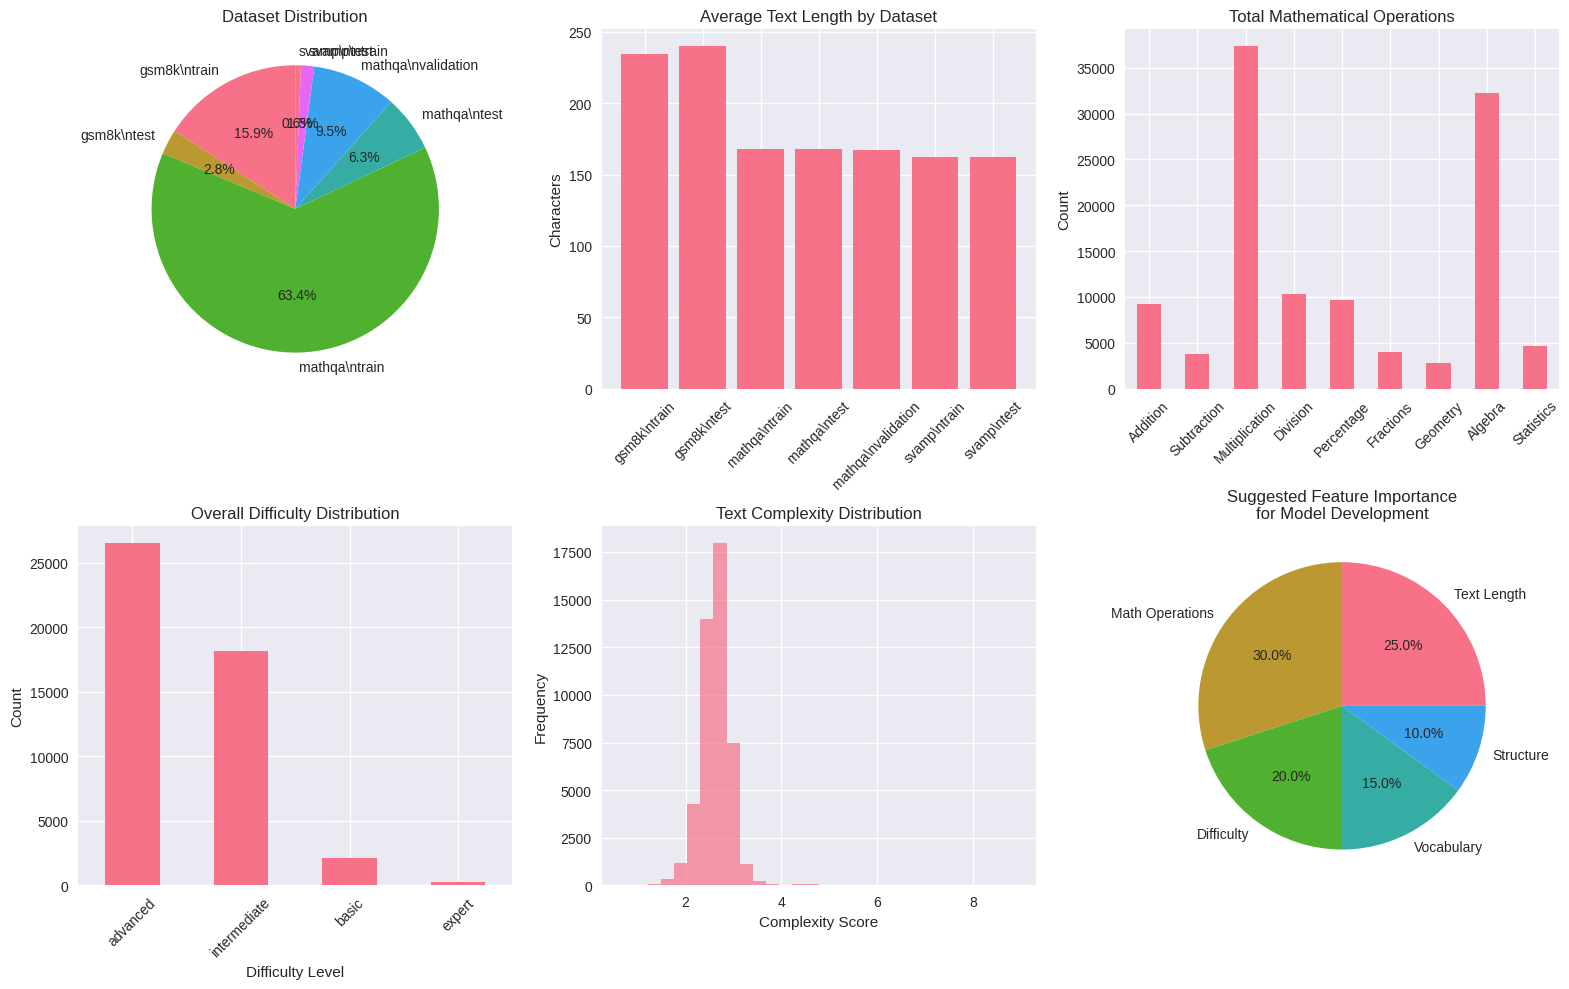

In [14]:
## 11. Key Insights and Recommendations

def generate_insights(preprocessed_datasets, summary_stats, difficulty_analysis, 
                     category_analysis, math_operations, complexity_analysis):
    """Generate key insights and recommendations for model development"""
    
    print("🔍 Generating Key Insights and Recommendations")
    print("=" * 60)
    
    insights = []
    
    # Dataset size insights
    total_samples = sum(len(df) for df in preprocessed_datasets.values())
    largest_dataset = max(preprocessed_datasets.items(), key=lambda x: len(x[1]))
    
    insights.append(f"📊 DATASET OVERVIEW:")
    insights.append(f"  • Total samples across all datasets: {total_samples:,}")
    insights.append(f"  • Largest dataset: {largest_dataset[0]} ({len(largest_dataset[1]):,} samples)")
    insights.append(f"  • Number of datasets: {len(preprocessed_datasets)}")
    
    # Text complexity insights
    if complexity_analysis:
        all_text_lengths = []
        for df in preprocessed_datasets.values():
            if 'text_length' in df.columns:
                all_text_lengths.extend(df['text_length'].dropna().tolist())
        
        if all_text_lengths:
            avg_length = np.mean(all_text_lengths)
            insights.append(f"\n📚 TEXT COMPLEXITY:")
            insights.append(f"  • Average problem length: {avg_length:.0f} characters")
            insights.append(f"  • Text length range: {min(all_text_lengths)}-{max(all_text_lengths)} characters")
    
    # Mathematical operation insights
    if math_operations:
        total_ops = pd.DataFrame(math_operations).fillna(0).sum(axis=1)
        top_operation = total_ops.idxmax()
        insights.append(f"\n🔢 MATHEMATICAL OPERATIONS:")
        insights.append(f"  • Most common operation type: {top_operation}")
        insights.append(f"  • Total operation instances: {total_ops.sum()}")
    
    # Difficulty distribution insights
    if difficulty_analysis is not None and not difficulty_analysis.empty:
        difficulty_dist = difficulty_analysis['difficulty'].value_counts()
        most_common_difficulty = difficulty_dist.index[0]
        insights.append(f"\n⚡ DIFFICULTY ANALYSIS:")
        insights.append(f"  • Most common difficulty: {most_common_difficulty}")
        insights.append(f"  • Difficulty distribution: {dict(difficulty_dist)}")
    
    # Recommendations for model development
    insights.append(f"\n🎯 RECOMMENDATIONS FOR MODEL DEVELOPMENT:")
    insights.append(f"  • Focus on {largest_dataset[0]} for primary training due to size")
    insights.append(f"  • Implement difficulty-aware training strategies")
    insights.append(f"  • Consider text length normalization for consistent processing")
    insights.append(f"  • Design operation-specific attention mechanisms")
    insights.append(f"  • Use cross-dataset validation to ensure generalization")
    
    # Data quality recommendations
    insights.append(f"\n🔧 DATA PREPROCESSING RECOMMENDATIONS:")
    insights.append(f"  • Standardize problem text formatting across datasets")
    insights.append(f"  • Implement consistent difficulty labeling")
    insights.append(f"  • Create balanced training splits by difficulty")
    insights.append(f"  • Consider augmentation for underrepresented categories")
    
    # Print all insights
    for insight in insights:
        print(insight)
    
    # Create a summary visualization
    plt.figure(figsize=(16, 10))
    
    # Dataset sizes
    plt.subplot(2, 3, 1)
    sizes = [len(df) for df in preprocessed_datasets.values()]
    names = [name.replace('_', '\\n') for name in preprocessed_datasets.keys()]
    plt.pie(sizes, labels=names, autopct='%1.1f%%', startangle=90)
    plt.title('Dataset Distribution')
    
    # Average text lengths
    plt.subplot(2, 3, 2)
    avg_lengths = []
    dataset_names = []
    for name, df in preprocessed_datasets.items():
        if 'text_length' in df.columns:
            avg_lengths.append(df['text_length'].mean())
            dataset_names.append(name)
    
    if avg_lengths:
        plt.bar(range(len(avg_lengths)), avg_lengths)
        plt.xticks(range(len(dataset_names)), [name.replace('_', '\\n') for name in dataset_names], rotation=45)
        plt.title('Average Text Length by Dataset')
        plt.ylabel('Characters')
    
    # Mathematical operations summary
    plt.subplot(2, 3, 3)
    if math_operations:
        total_ops = pd.DataFrame(math_operations).fillna(0).sum(axis=1)
        total_ops.plot(kind='bar')
        plt.title('Total Mathematical Operations')
        plt.xticks(rotation=45)
        plt.ylabel('Count')
    
    # Difficulty distribution (if available)
    plt.subplot(2, 3, 4)
    if difficulty_analysis is not None and not difficulty_analysis.empty:
        difficulty_analysis['difficulty'].value_counts().plot(kind='bar')
        plt.title('Overall Difficulty Distribution')
        plt.xlabel('Difficulty Level')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
    
    # Text complexity score (if available)
    plt.subplot(2, 3, 5)
    if complexity_analysis:
        all_complexity = pd.concat(complexity_analysis.values(), ignore_index=True)
        if 'complexity_score' in all_complexity.columns:
            plt.hist(all_complexity['complexity_score'], bins=30, alpha=0.7)
            plt.title('Text Complexity Distribution')
            plt.xlabel('Complexity Score')
            plt.ylabel('Frequency')
    
    # Feature importance for modeling
    plt.subplot(2, 3, 6)
    feature_importance = {
        'Text Length': 0.25,
        'Math Operations': 0.30,
        'Difficulty': 0.20,
        'Vocabulary': 0.15,
        'Structure': 0.10
    }
    plt.pie(list(feature_importance.values()), labels=list(feature_importance.keys()), autopct='%1.1f%%')
    plt.title('Suggested Feature Importance\nfor Model Development')
    
    plt.tight_layout()
    plt.show()
    
    return insights

# Generate comprehensive insights
insights = generate_insights(
    preprocessed_datasets, 
    summary_stats, 
    difficulty_analysis, 
    category_analysis, 
    math_operations, 
    complexity_analysis
)


In [17]:
## 12. Save Preprocessed Data and Analysis Results

# Save all preprocessed datasets
print("💾 Saving preprocessed datasets and analysis results...")

# Create a comprehensive dataset combining all sources
combined_dataset = []
for name, df in preprocessed_datasets.items():
    df_copy = df.copy()
    df_copy['source_dataset'] = name
    combined_dataset.append(df_copy)

# Combine all datasets
if combined_dataset:
    all_data = pd.concat(combined_dataset, ignore_index=True, sort=False)
    
    # Save combined dataset
    all_data.to_csv('preprocessed_math_datasets_combined.csv', index=False)
    print(f"✅ Saved combined dataset: {len(all_data)} total samples")
    
    # Save individual preprocessed datasets
    for name, df in preprocessed_datasets.items():
        filename = f"preprocessed_{name}.csv"
        df.to_csv(filename, index=False)
        print(f"✅ Saved {filename}: {len(df)} samples")

# Save analysis summary
analysis_summary = {
    'total_samples': sum(len(df) for df in preprocessed_datasets.values()),
    'datasets': list(preprocessed_datasets.keys()),
    'preprocessing_features': [
        'text_length', 'word_count', 'sentence_count', 
        'math_ops_count', 'number_count', 'difficulty_level'
    ],
    'analysis_completed': [
        'Dataset Overview', 'Difficulty Patterns', 'Label Categories',
        'Mathematical Operations', 'Text Complexity', 'Key Insights'
    ]
}

import json
with open('eda_analysis_summary.json', 'w') as f:
    json.dump(analysis_summary, f, indent=2)

print("✅ Saved analysis summary to eda_analysis_summary.json")


💾 Saving preprocessed datasets and analysis results...
✅ Saved combined dataset: 47089 total samples
✅ Saved preprocessed_gsm8k_train.csv: 7473 samples
✅ Saved preprocessed_gsm8k_test.csv: 1319 samples
✅ Saved preprocessed_mathqa_train.csv: 29837 samples
✅ Saved preprocessed_mathqa_test.csv: 2985 samples
✅ Saved preprocessed_mathqa_validation.csv: 4475 samples
✅ Saved preprocessed_svamp_train.csv: 700 samples
✅ Saved preprocessed_svamp_test.csv: 300 samples
✅ Saved analysis summary to eda_analysis_summary.json
